# Project 3 - Aircraft Classification

## Experiment 1: Unfrozen ResNet18 + AdamW + CosineAnnealingLR

Import essential libraries and default configurations

### Google Colab Setup

In [58]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [59]:
%cd drive/MyDrive/project/aircraft_classification
%ls -la

[Errno 2] No such file or directory: 'drive/MyDrive/project/aircraft_classification'
/content/drive/MyDrive/project/aircraft_classification
total 43897
drwx------ 2 root root     4096 Aug 20 20:26 dinov3/
drwx------ 4 root root     4096 Aug 20 01:15 FGVCAircraft_Subset20/
drwx------ 2 root root     4096 Aug 20 20:38 __pycache__/
-rw------- 1 root root 44828427 Aug 20 23:04 resnet_unfrozen_h1_best.pth
-rw------- 1 root root    97772 Aug 20 23:05 training_results_model_h1.png
-rw------- 1 root root     5579 Aug 20 14:01 utils.py
drwx------ 2 root root     4096 Aug 20 20:26 weights/
-rw------- 1 root root     1636 Aug 20 23:05 weights_model_h1.pkl


In [60]:
# # Reload all modules before executing the notebook
# %load_ext autoreload
# %autoreload 2

In [61]:
from utils import set_seed, plot_class_distribution, setup_model, train_epoch, eval_epoch

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn for machine learning utilities
from sklearn.model_selection import train_test_split

# Torch for deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Torchvision for datasets and transformations
import torchvision
import torchvision.transforms as transforms

# Progress bar for loops
import tqdm
import copy
import random

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Fix random seedataset for reproducibility
set_seed(42)

Using device: cuda


## Data Preprocessing

Number of training/validation samples: 1331
Number of test samples: 669


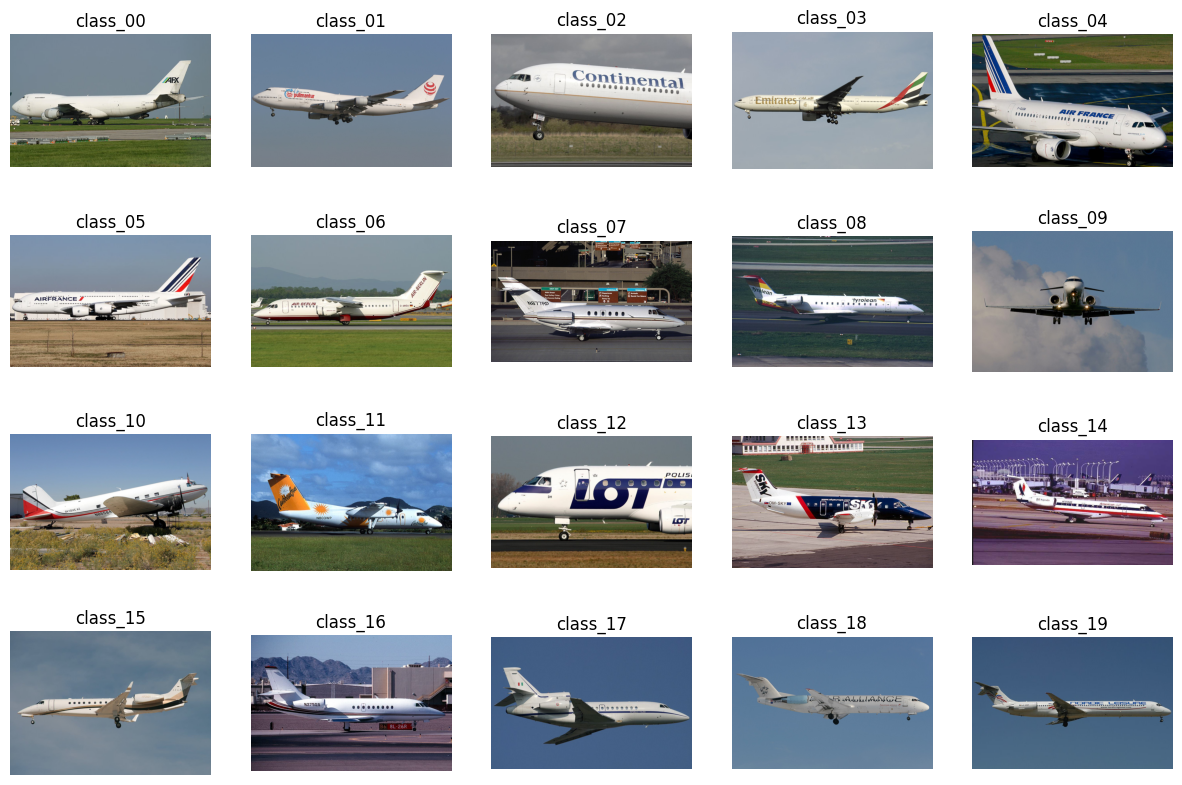

In [63]:
# Load dataset
trainval_dataset = torchvision.datasets.ImageFolder('FGVCAircraft_Subset20/trainval')
test_dataset = torchvision.datasets.ImageFolder('FGVCAircraft_Subset20/test')

print(f"Number of training/validation samples: {len(trainval_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

# Get class names
class_names = trainval_dataset.classes
dataset_labels = np.array([label for _, label in trainval_dataset.samples])

# Plot one random sample from each class in the training/validation dataset
num_classes = len(trainval_dataset.classes)
plt.figure(figsize=(15, 10))

# For each class, select a random sample and plot it
for i in range(num_classes):
    class_indices = [j for j, (_, label) in enumerate(trainval_dataset.samples) if label == i]
    random_index = random.choice(class_indices)
    image, label = trainval_dataset[random_index]
    plt.subplot(4, 5, i + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis('off')

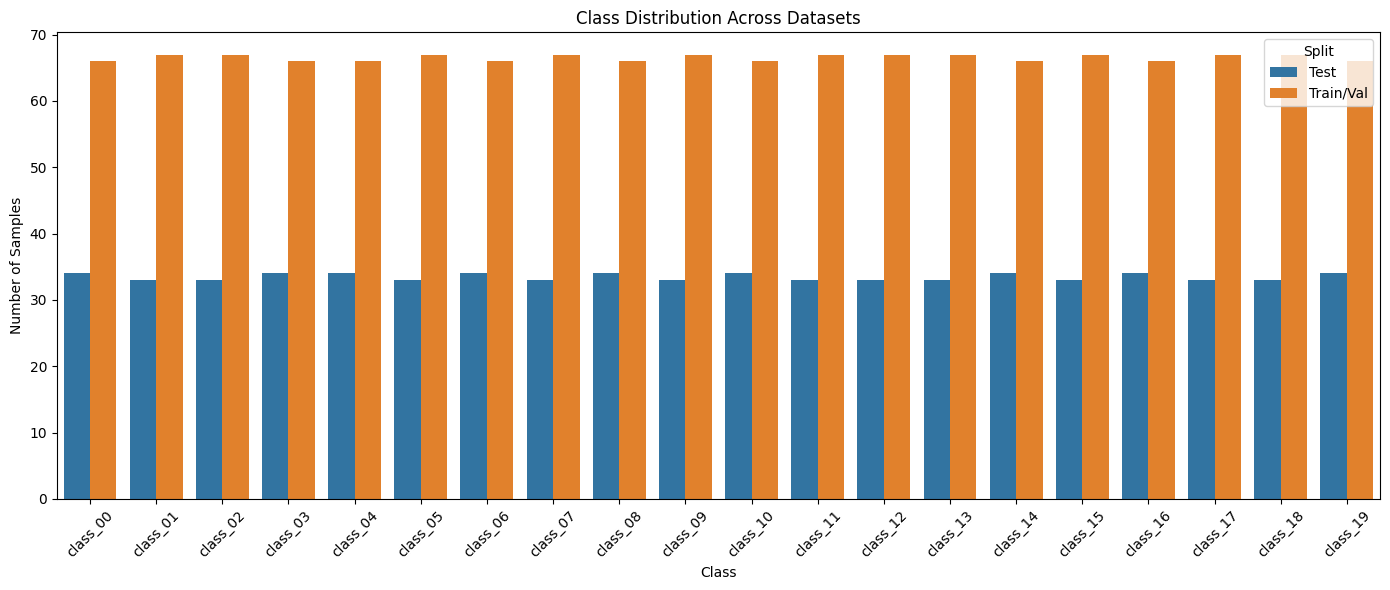

In [64]:
# Plot class distribution of the training/validation and test dataset

plot_class_distribution(trainval_dataset, test_dataset, dataset_names=['Train/Val', 'Test'])

Total training/validation samples: 1331
Number of training samples: 1064
Number of validation samples: 267


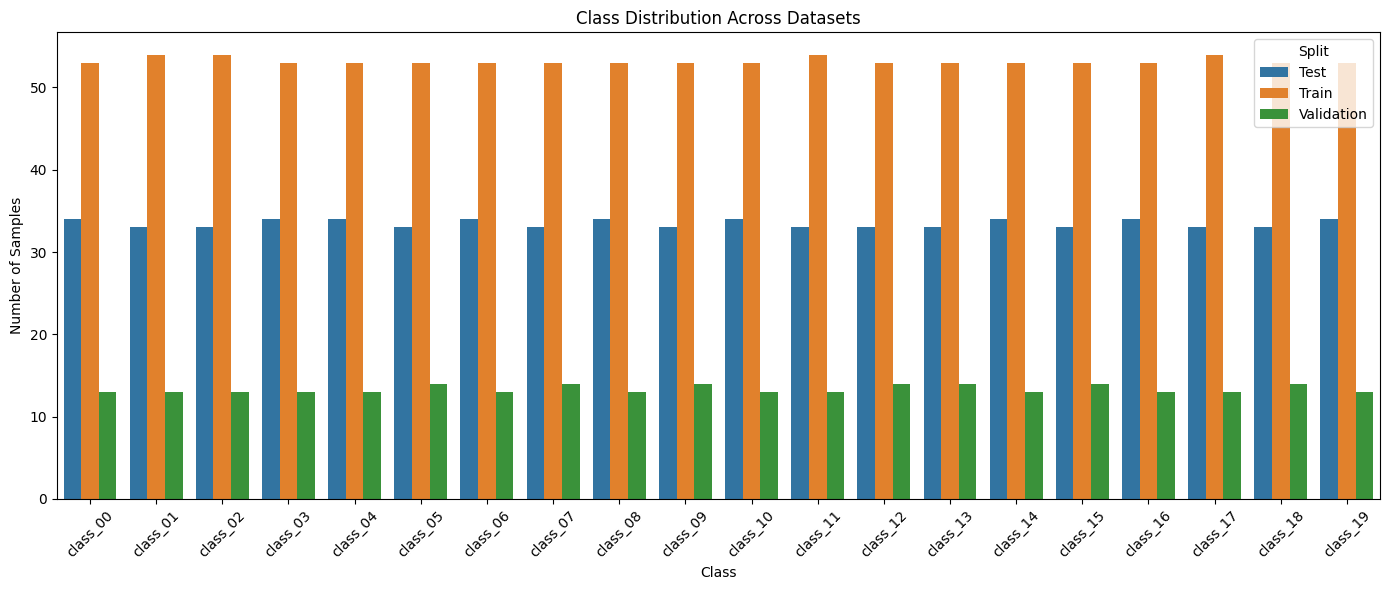

In [65]:
# Splitting dataset
indices = list(range(len(trainval_dataset)))
labels = [label for _, label in trainval_dataset.samples]

# Perform stratified split to maintain class distribution
train_indices, val_indices = train_test_split(
    indices, test_size=0.2, stratify=labels, random_state=42)

# Create subset datasets
train_dataset = torch.utils.data.Subset(trainval_dataset, train_indices)
val_dataset = torch.utils.data.Subset(copy.deepcopy(trainval_dataset), val_indices)

print(f"Total training/validation samples: {len(trainval_dataset)}")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
plot_class_distribution(train_dataset, val_dataset, test_dataset, dataset_names=['Train', 'Validation', 'Test'])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


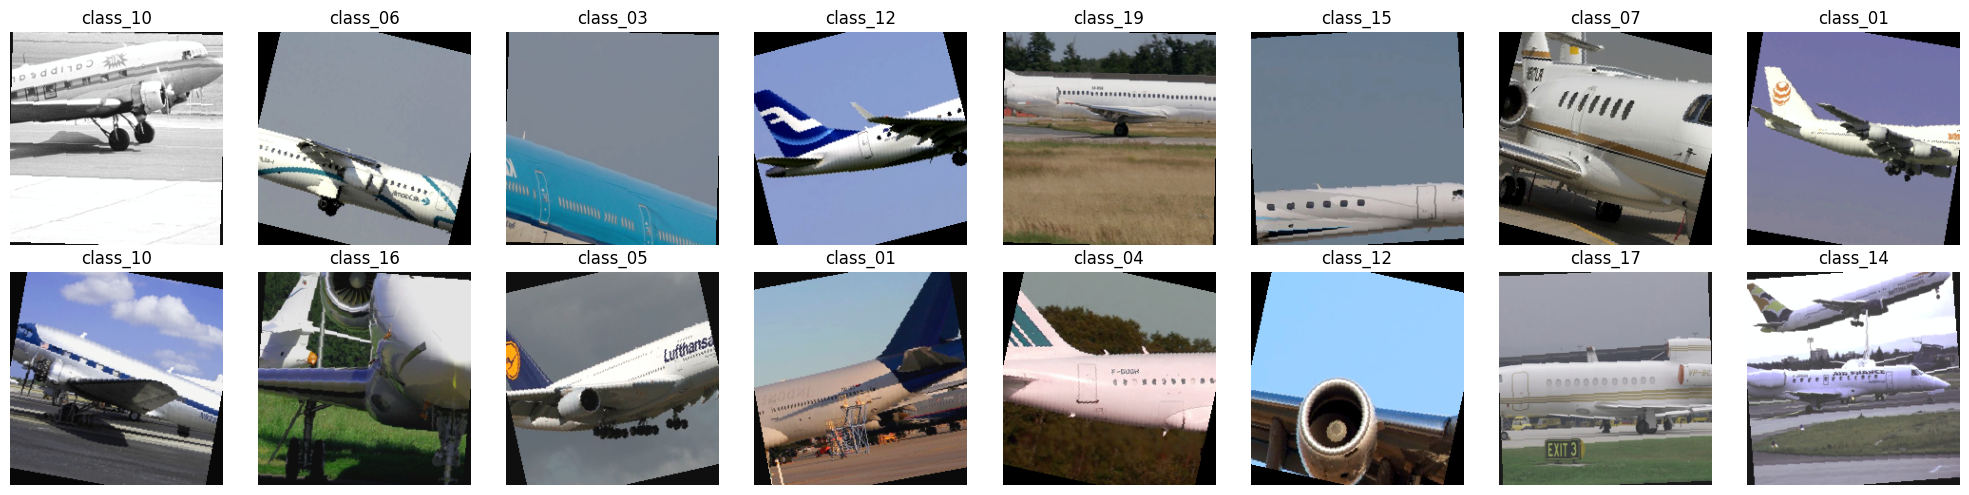

In [66]:
# Imagenet preprocessing
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Base transformation (tensor + norm)
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Validation / Test transform
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    base_transform
])

# Data augmentation transformations for training dataset
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    base_transform
])

# Apply transformations to datasets
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

# Create DataLoaders for training, validation, and test datasets
batch_size = 16
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Visualize a batch of training images
data_iter = iter(train_loader)
images, labels = next(data_iter)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
axes = axes.ravel()
for i in range(min(16, len(images))):
    img = images[i].numpy().transpose((1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
    img = img * np.array(imagenet_std) + np.array(imagenet_mean)  # Unnormalize
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis('off')
plt.tight_layout()


### Model

In [67]:
# Initialize Unfrozen ResNet-18
backbone_model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_unfrozen = setup_model(backbone_model, 20, freeze_backbone=False, device=device)
print("Initialized Unfrozen ResNet-18")
resnet_unfrozen

Initialized Unfrozen ResNet-18


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Training Loop

  2%|▏         | 1/64 [00:19<20:38, 19.66s/it]

Epoch [  1/64] | train_loss: 2.9625 | train_acc: 0.1109 | val_loss: 3.6784 | val_acc: 0.0448
Best model found at epoch 0 with accuracy of 0.045


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  3%|▎         | 2/64 [00:42<22:01, 21.31s/it]

Epoch [  2/64] | train_loss: 2.5987 | train_acc: 0.1870 | val_loss: 2.6786 | val_acc: 0.1736
Best model found at epoch 1 with accuracy of 0.174


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  5%|▍         | 3/64 [01:02<21:08, 20.80s/it]

...

Epoch [ 46/64] | train_loss: 0.4935 | train_acc: 0.8271 | val_loss: 0.7850 | val_acc: 0.7755


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
 73%|███████▎  | 47/64 [15:48<05:38, 19.88s/it]

Epoch [ 47/64] | train_loss: 0.4951 | train_acc: 0.8365 | val_loss: 0.6713 | val_acc: 0.8082


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
 73%|███████▎  | 47/64 [16:07<05:49, 20.58s/it]


Epoch [ 48/64] | train_loss: 0.4584 | train_acc: 0.8506 | val_loss: 0.6768 | val_acc: 0.8173
Early stopping triggered after 48 epochs!


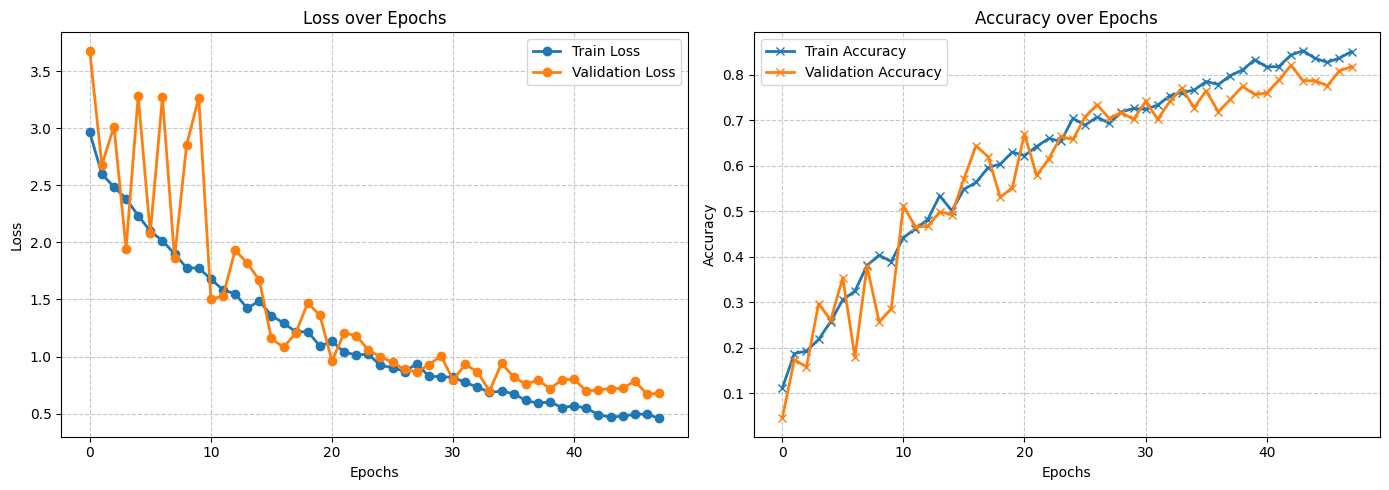

In [68]:
# Hyperparmeters setup
lr = 0.001
total_epochs = 64

# Define a loss function
criterion = nn.CrossEntropyLoss()

# Initialise the AdamW optimizer (filter out frozen parameters)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet_unfrozen.parameters()), lr=lr, weight_decay=1e-4
)

# Initialize Cosine Annealing Learning Rate Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)

# For n epochs
total_train_loss, total_val_loss = [], []
total_train_acc, total_val_acc = [], []
best_acc = -np.inf
patience = 5
epochs_no_improve = 0

epoch_pbar = tqdm.tqdm(range(total_epochs), colour='blue')
for epoch in epoch_pbar:
    # Train for 1 epoch
    mean_train_loss, train_accuracy = train_epoch(resnet_unfrozen, train_loader, criterion, optimizer, epoch, device)
    total_train_loss.append(mean_train_loss)
    total_train_acc.append(train_accuracy)

    # Step the scheduler
    scheduler.step()

    # Evaluate on validation set
    mean_val_loss, val_accuracy = eval_epoch(
        resnet_unfrozen, val_loader, criterion, epoch, device
    )
    total_val_loss.append(mean_val_loss)
    total_val_acc.append(val_accuracy)
    
    # Print formatted string above the progress bar
    epoch_pbar.write(f"Epoch [{epoch+1:3d}/{total_epochs}] | train_loss: {mean_train_loss:.4f} | train_acc: {train_accuracy:.4f} | val_loss: {mean_val_loss:.4f} | val_acc: {val_accuracy:.4f}")

    # Save the best model based on validation accuracy
    if val_accuracy > best_acc:
        torch.save(resnet_unfrozen.state_dict(), "resnet_unfrozen_h1_best.pth")
        best_acc = val_accuracy
        epochs_no_improve = 0
        print(f"Best model found at epoch {epoch} with accuracy of {best_acc:.3f}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break

# Plot training and validation loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss subplot
axes[0].plot(total_train_loss, label='Train Loss', marker='o', linewidth=2)
axes[0].plot(total_val_loss, label='Validation Loss', marker='o', linewidth=2)
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')

# Accuracy subplot
axes[1].plot(total_train_acc, label='Train Accuracy', marker='x', linewidth=2)
axes[1].plot(total_val_acc, label='Validation Accuracy', marker='x', linewidth=2)
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')

for ax in axes:
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('training_results_model_h1.png')


In [69]:
import pickle
weights_model_h1 = {
    'train_loss': total_train_loss, 'val_loss': total_val_loss,
    'train_acc': total_train_acc, 'val_acc': total_val_acc
}
with open('weights_model_h1.pkl', 'wb') as f:
    pickle.dump(weights_model_h1, f)
print("Saved training history to weights_model_h1.pkl")

Saved training history to weights_model_h1.pkl
